## Rest of file types

In [1]:
#Initialize Notebook Environment
from pathlib import Path
import sys
sys.path.insert( 0, Path("../..").resolve().absolute().__str__() )

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xaidar.filesUtils import loadPickle

xc_dataDir = Path( "../../../data/s3Sizes/xchem/filetypes" )
xc_dataStats = loadPickle( xc_dataDir / "stats_filetype_sizes.pkl" )
xc_dataStats_df = pd.DataFrame( xc_dataStats )

pd_dataDir = Path( "../../../data/s3Sizes/pandda/filetypes" )
pd_dataStats = loadPickle( pd_dataDir / "stats_filetype_sizes.pkl" )
pd_dataStats_df = pd.DataFrame( pd_dataStats )

print( "XChem Data Statistics:" )
display( xc_dataStats_df.head(2))
print( "Pandda Data Statistics:" )
display( pd_dataStats_df.head(2) )


XChem Data Statistics:


,File Type,Files Count,Median,Mean,Std,1stQrt,3rdQrt,QrtDeviation,Max,Min,Sum
0,.csv,492956,1860.0,13679.315385,3.242432e+05,1356.0,3357.0,1000.5,80906623,0,6743300595
1,.txt,3458488,10672.0,304168.266793,3.178951e+06,1380.0,25226.0,11923.0,487143107,0,1051962300685


Pandda Data Statistics:


,File Type,Files Count,Median,Mean,Std,1stQrt,3rdQrt,QrtDeviation,Max,Min,Sum
0,.csv,168,61908.0,239908.482143,489547.716090,23280.75,228948.0,102833.625,3606844,3,40304625
1,.log,608435,9143.0,20228.220240,22693.793181,738.00,39411.0,19336.500,309100,0,12307557182


## How many filetypes exist

In [4]:
dfs = [xc_dataStats_df, pd_dataStats_df]
for df, bucket in zip( dfs, ["xchem", "pandda"]):
    print(f"{bucket} bucket number of file types: {len(df)}")


xchem bucket number of file types: 266532
pandda bucket number of file types: 151


## Sort file types by storage size and number of files

In [5]:
# Instantiate Objects to Plot
from copy import deepcopy
xc_sums =  xc_dataStats_df.sort_values( by=[ "Sum"], ascending=[False] )
xc_sums_display = deepcopy( xc_sums )
xc_counts =  xc_dataStats_df.sort_values( by=[ "Files Count"], ascending=[False] ) 
xc_counts_display = deepcopy( xc_counts )

pd_sums =  pd_dataStats_df.sort_values( by=[ "Sum"], ascending=[False] )
pd_sums_display = deepcopy( pd_sums )
pd_counts =  pd_dataStats_df.sort_values( by=[ "Files Count"], ascending=[False] ) 
pd_counts_display = deepcopy( pd_counts )


## Reorganise dataframes for better 

In [6]:
from xaidar.filesUtils import roundBytes
import numpy as np
display( xc_sums_display.head() )

def rounding( value):
    # if type(value) is not int or type(value) is not float or type(value) is not np.int64 or type(value) is not np.float64 :
    #     return value
    # else:
    """Round bytes to a more readable format."""
    size, unit = roundBytes( int(value) )
    return f"{str(size)} {unit}"

dataframes_dict = {
    "xc_sums_display": xc_sums_display,
    "xc_counts_display": xc_counts_display,
    "pd_sums_display": pd_sums_display,
    "pd_counts_display": pd_counts_display
}

for name, df in dataframes_dict.items():
    first_cols = ["File Type", "Sum", "Files Count"]
    other_cols = [col for col in df.columns if col not in first_cols]
    new_order = first_cols + other_cols
    
    # Reassign the DataFrame in the dictionary
    dataframes_dict[name] = df[new_order]
    
    dataframes_dict[name]["Sum"] = dataframes_dict[name]["Sum"].apply(rounding)



xc_sums_display, xc_counts_display, pd_sums_display, pd_counts_display = dataframes_dict["xc_sums_display"], dataframes_dict["xc_counts_display"], dataframes_dict["pd_sums_display"], dataframes_dict["pd_counts_display"]
display( xc_sums_display.head() )

,File Type,Files Count,Median,Mean,Std,1stQrt,3rdQrt,QrtDeviation,Max,Min,Sum
337,.ccp4,2007939,13997824.0,2.158211e+07,2.579182e+07,7373904.0,24884304.0,8755200.0,924209200,0,43335563627385
11,.mtz,7623701,2385004.0,4.933639e+06,1.082866e+07,1165696.0,4761852.0,1798078.0,1704377676,0,37612329367516
32,.HKL,239844,45560917.0,6.735328e+07,7.415705e+07,22176110.0,97205727.0,37514808.5,2514632923,0,16154280659151
60,.cbf,2765791,6230021.0,5.584968e+06,1.857624e+06,6229955.0,6230235.0,140.0,18784256,584,15446855042783
13,.pickle,1304058,174615.0,8.442928e+06,1.365333e+08,56619.5,1774416.5,858898.5,41406355830,5,11010043059193


,File Type,Sum,Files Count,Median,Mean,Std,1stQrt,3rdQrt,QrtDeviation,Max,Min
337,.ccp4,43.34 TB,2007939,13997824.0,2.158211e+07,2.579182e+07,7373904.0,24884304.0,8755200.0,924209200,0
11,.mtz,37.61 TB,7623701,2385004.0,4.933639e+06,1.082866e+07,1165696.0,4761852.0,1798078.0,1704377676,0
32,.HKL,16.15 TB,239844,45560917.0,6.735328e+07,7.415705e+07,22176110.0,97205727.0,37514808.5,2514632923,0
60,.cbf,15.45 TB,2765791,6230021.0,5.584968e+06,1.857624e+06,6229955.0,6230235.0,140.0,18784256,584
13,.pickle,11.01 TB,1304058,174615.0,8.442928e+06,1.365333e+08,56619.5,1774416.5,858898.5,41406355830,5


---

# Displaying Data - xchem Bucket

## Interactive xchem bucket table display

In [64]:
numb_fileTypes = 20
start_rank = 0
end_rank = start_rank + numb_fileTypes

In [68]:

# display( xc_sums.iloc[:10])
print(f"Current Rank: {start_rank} to {end_rank}")
print( f"Out of {len(xc_sums)} file types")
display( xc_sums_display.iloc[start_rank:end_rank])
start_rank , end_rank = start_rank + numb_fileTypes , end_rank  + numb_fileTypes

Current Rank: 60 to 80
Out of 266532 file types


,File Type,Sum,Files Count,Median,Mean,Std,1stQrt,3rdQrt,QrtDeviation,Max,Min
13593,dif-.csv,9.83 GB,542,8.550000e+02,1.814489e+07,1.415220e+08,6.862500e+02,4.867750e+03,2.090750e+03,2224077069,0
166094,.nfs00000000a579c25f00000013,9.73 GB,1,9.734263e+09,9.734263e+09,0.000000e+00,9.734263e+09,9.734263e+09,0.000000e+00,9734262784,9734262784
40,.pck,8.87 GB,115262,5.324800e+04,7.693417e+04,6.594075e+04,2.867200e+04,1.105920e+05,4.096000e+04,491520,4096
185404,.expt,8.69 GB,54727,4.628900e+04,1.588184e+05,1.923375e+05,4.628400e+04,2.425670e+05,9.814150e+04,3172549,1677
152639,.o,8.05 GB,4898,7.099200e+04,1.644316e+06,3.245199e+07,1.700800e+04,2.386480e+05,1.108200e+05,1371756267,54
167105,.mask,7.23 GB,1163,6.224156e+06,6.213463e+06,2.576347e+05,6.224156e+06,6.224156e+06,0.000000e+00,6224156,4462
167655,.os,7.19 GB,10545,1.918880e+05,6.813719e+05,1.377513e+06,7.340800e+04,6.059440e+05,2.662680e+05,48100104,944
129,dif-.pickle,7.17 GB,9010,4.464000e+03,7.961353e+05,2.340754e+07,2.940000e+02,2.445100e+04,1.207850e+04,1028436143,0
13049,.lis,7.05 GB,775333,2.024000e+03,9.094404e+03,8.633161e+04,2.860000e+02,5.303000e+03,2.508500e+03,2171862,0
0,.csv,6.74 GB,492956,1.860000e+03,1.367932e+04,3.242432e+05,1.356000e+03,3.357000e+03,1.000500e+03,80906623,0


## Interactive xchem bucket pie chart display

In [9]:
numb_fileTypes = 10
start_rank = 0
end_rank = start_rank + numb_fileTypes

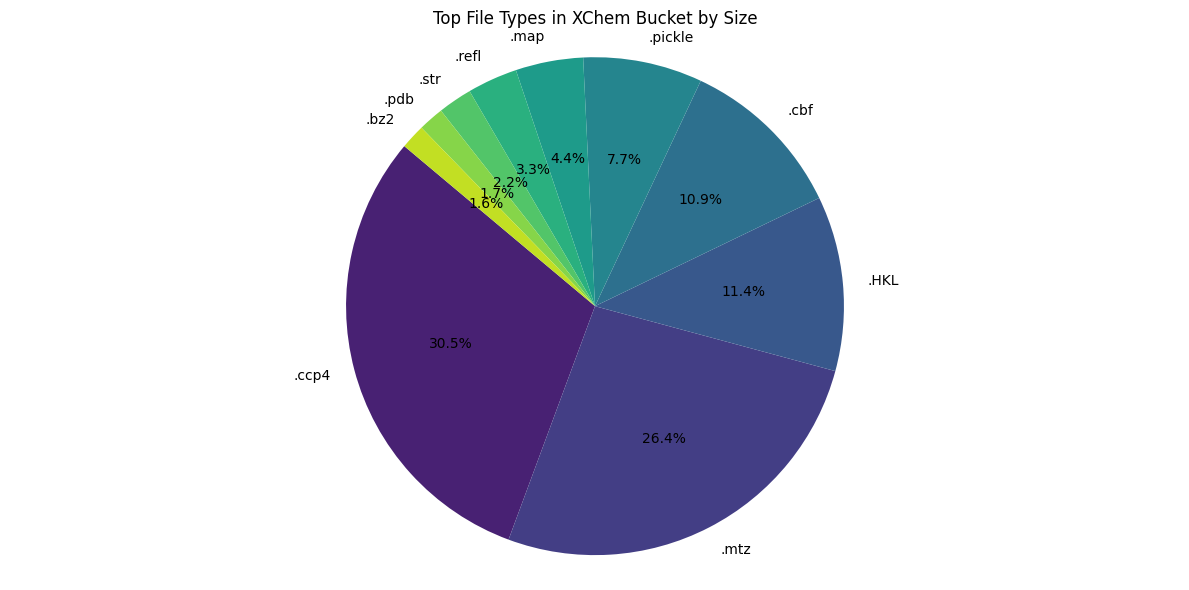

In [10]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 6))
#Plot pie chart for XChem file types
plt.pie( xc_sums["Sum"].iloc[start_rank:end_rank],
         labels=xc_sums["File Type"].iloc[start_rank:end_rank],
         autopct='%1.1f%%',
         startangle=140,
         colors=sns.color_palette("viridis", numb_fileTypes)   )
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title("Top File Types in XChem Bucket by Size")
plt.tight_layout()
plt.show()
start_rank , end_rank = start_rank + numb_fileTypes , end_rank  + numb_fileTypes

## Interactive xchem bucket bar chart display

In [11]:
numb_fileTypes = 30
start_rank = 0
end_rank = start_rank + numb_fileTypes

/tmp/ipykernel_1088817/2340406159.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=xc_sums[["File Type","Sum"]].iloc[lst], x="File Type", y="Sum", palette="viridis")


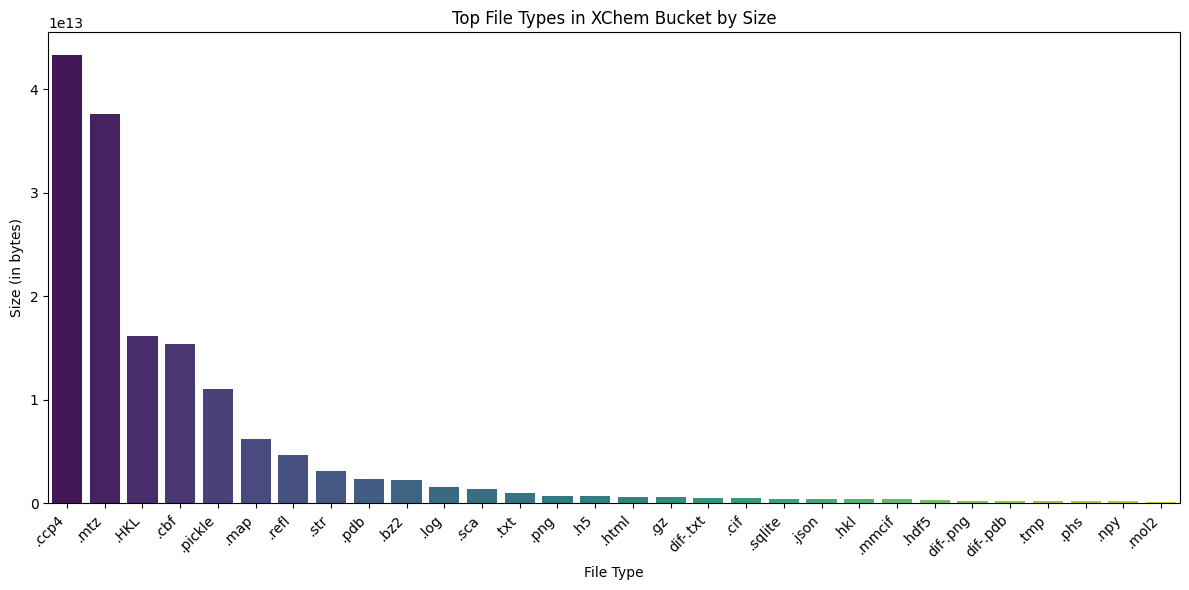

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

lst= [0] + list(range(start_rank,end_rank))
lst=  list(range(start_rank,end_rank))

plt.figure(figsize=(12, 6))
sns.barplot(data=xc_sums[["File Type","Sum"]].iloc[lst], x="File Type", y="Sum", palette="viridis")
plt.xticks(rotation=45, ha='right')
plt.title("Top File Types in XChem Bucket by Size")
plt.xlabel("File Type")
plt.ylabel("Size (in bytes)")
plt.tight_layout()
plt.show()
start_rank , end_rank = start_rank + numb_fileTypes , end_rank  + numb_fileTypes

# Displaying Data - xchem Bucket

## Interactive xchem bucket table display

In [13]:
numb_fileTypes = 20
start_rank = 0
end_rank = start_rank + numb_fileTypes

In [14]:

# display( xc_sums.iloc[:10])
print(f"Current Rank: {start_rank} to {end_rank}")
print( f"Out of {len(pd_sums)} file types")
display( pd_sums_display.iloc[start_rank:end_rank])
start_rank , end_rank = start_rank + numb_fileTypes , end_rank  + numb_fileTypes

Current Rank: 0 to 20
Out of 151 file types


,File Type,Sum,Files Count,Median,Mean,Std,1stQrt,3rdQrt,QrtDeviation,Max,Min
7,.ccp4,7.79 TB,900842,5530704.0,8.649300e+06,1.038603e+07,248560.0,1.327214e+07,6.511792e+06,77761104,10464
8,.mtz,336.01 GB,96111,2682164.0,3.496107e+06,2.939504e+06,1431892.0,4.686292e+06,1.627200e+06,88480008,13844
6,.pdb,264.4 GB,2053436,8465.0,1.287621e+05,3.349335e+05,2852.0,1.056000e+04,3.854000e+03,2435190,0
4,.out,28.37 GB,189,9232.0,1.501061e+08,3.517634e+08,5.0,1.638839e+08,8.194196e+07,3130718639,5
9,.pickle,26.29 GB,198106,130539.0,1.327135e+05,3.967279e+04,107344.0,1.485478e+05,2.060188e+04,520490,5471
1,.log,12.31 GB,608435,9143.0,2.022822e+04,2.269379e+04,738.0,3.941100e+04,1.933650e+04,309100,0
10,.cif,4.04 GB,386795,10179.0,1.044170e+04,3.157289e+03,8542.0,1.190900e+04,1.683500e+03,51155,0
2,.json,2.39 GB,417616,668.0,5.722870e+03,1.086073e+05,2.0,1.272000e+03,6.350000e+02,34433022,2
31,.mmcif,1.15 GB,81051,14029.0,1.413648e+04,2.965784e+03,12180.0,1.541900e+04,1.619500e+03,29296,6031
12,dif-.pdb,780.4 MB,24725,22476.0,3.156314e+04,3.127987e+04,11653.0,4.040900e+04,1.437800e+04,666642,10


## Interactive xchem bucket pie chart display

In [15]:
numb_fileTypes = 10
start_rank = 0
end_rank = start_rank + numb_fileTypes

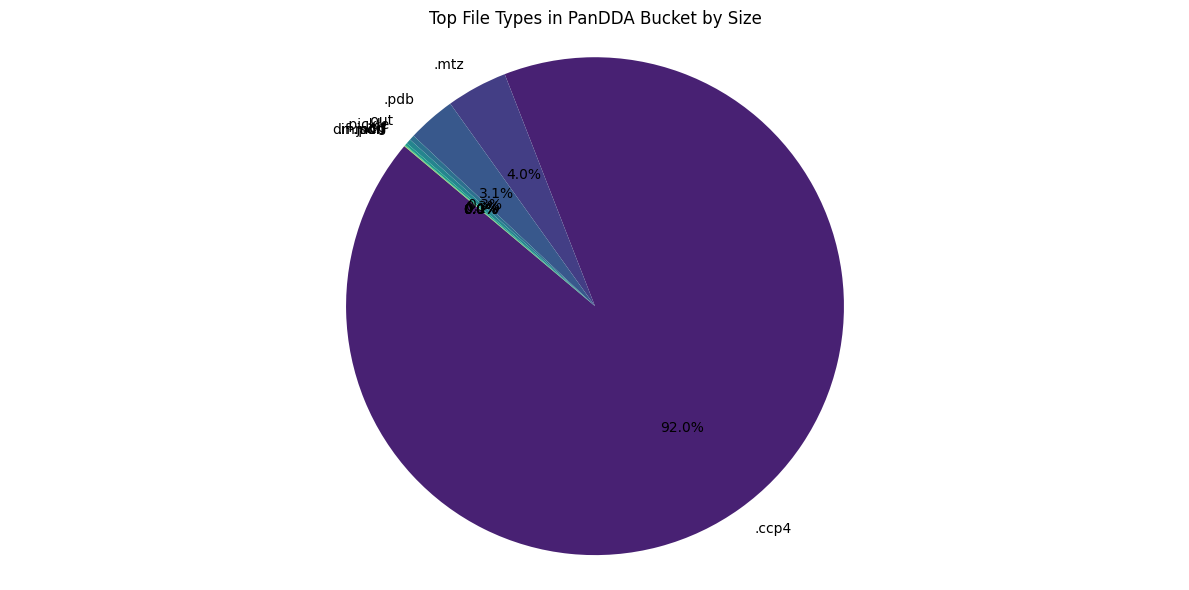

In [16]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 6))
#Plot pie chart for XChem file types
plt.pie( pd_sums["Sum"].iloc[start_rank:end_rank],
         labels=pd_sums["File Type"].iloc[start_rank:end_rank],
         autopct='%1.1f%%',
         startangle=140,
         colors=sns.color_palette("viridis", numb_fileTypes)   )
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title("Top File Types in PanDDA Bucket by Size")
plt.tight_layout()
plt.show()
start_rank , end_rank = start_rank + numb_fileTypes , end_rank  + numb_fileTypes

## Interactive xchem bucket bar chart display

In [17]:
numb_fileTypes = 30
start_rank = 0
end_rank = start_rank + numb_fileTypes

/tmp/ipykernel_1088817/3372808630.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pd_sums[["File Type","Sum"]].iloc[lst], x="File Type", y="Sum", palette="viridis")


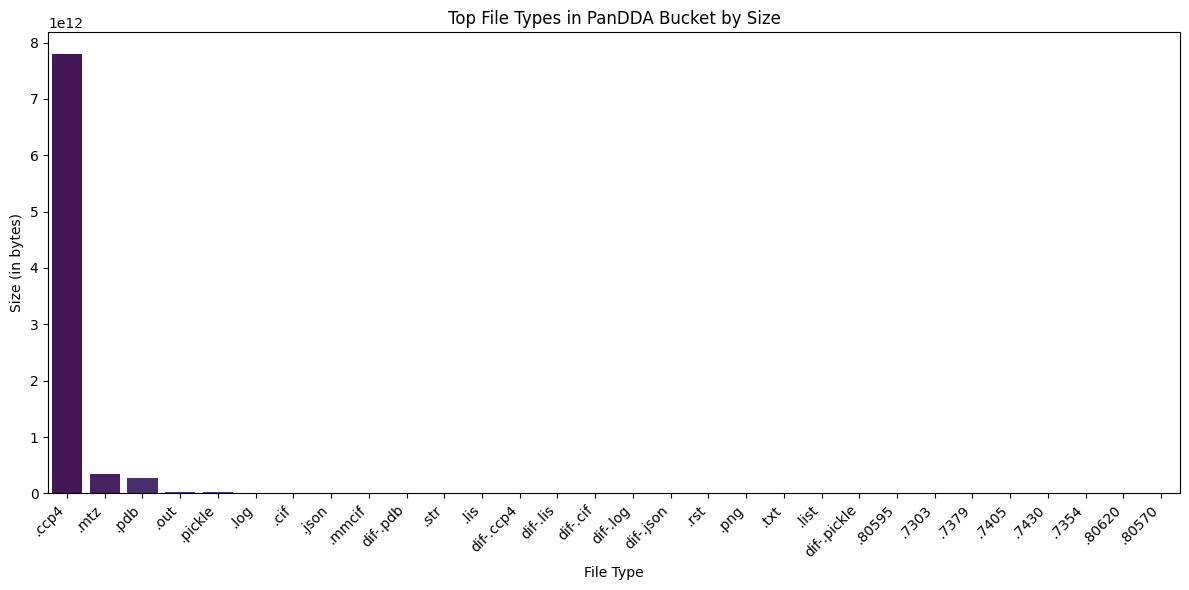

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

lst= [0] + list(range(start_rank,end_rank))
lst=  list(range(start_rank,end_rank))

plt.figure(figsize=(12, 6))
sns.barplot(data=pd_sums[["File Type","Sum"]].iloc[lst], x="File Type", y="Sum", palette="viridis")
plt.xticks(rotation=45, ha='right')
plt.title("Top File Types in PanDDA Bucket by Size")
plt.xlabel("File Type")
plt.ylabel("Size (in bytes)")
plt.tight_layout()
plt.show()
start_rank , end_rank = start_rank + numb_fileTypes , end_rank  + numb_fileTypes

## Without weird Files

In [369]:
import re
xc_lstFileTypes = list(xc_dataStats_df["File Type"].values)

xc_removedFileTypes = [ file for file in list(xc_lstFileTypes) if re.search( "^\\....[0-9][0-9][0-9]", file) ] 
xc_updatedFileTypes = [ file for file in list(xc_lstFileTypes) if not re.search( "^\\....[0-9][0-9][0-9]", file)]

xc_removedFileTypes.extend( [ file for file in xc_updatedFileTypes if  re.search( "^\\.[0-9][0-9][0-9][0-9]", file)] )# i.e. .21610_VDW_R
xc_updatedFileTypes = [ file for file in xc_updatedFileTypes if not re.search( "^\\.[0-9][0-9][0-9][0-9]", file)]  # i.e. .21610_VDW_R

xc_removedFileTypes.extend( [ file for file in xc_updatedFileTypes if  re.search( "[0-9][0-9][0-9][0-9][0-9][0-9][0-9]", file)] )
xc_updatedFileTypes = [ file for file in xc_updatedFileTypes if not re.search( "[0-9][0-9][0-9][0-9][0-9][0-9][0-9]", file)]  


xc_updatedFileTypes = sorted( xc_updatedFileTypes)
xc_removedFileTypes = sorted( xc_removedFileTypes)

print(f"Number of File types after removing odds ones: {len(xc_updatedFileTypes)}")
print(f"Number of Removed File types: {len(xc_removedFileTypes)}")

pd_lstFileTypes = list(pd_dataStats_df["File Type"].values)

pd_removedFileTypes = [ file for file in list(pd_lstFileTypes) if re.search( "^\\....[0-9][0-9][0-9]", file) ]
pd_updatedFileTypes = [ file for file in list(pd_lstFileTypes) if not re.search( "^\\....[0-9][0-9][0-9]", file)]

pd_removedFileTypes.extend( [ file for file in pd_updatedFileTypes if  re.search( "^\\.[0-9][0-9][0-9][0-9]", file)] )# i.e. .21610_VDW_R
pd_updatedFileTypes = [ file for file in pd_updatedFileTypes if not re.search( "^\\.[0-9][0-9][0-9][0-9]", file)]  # i.e. .21610_VDW_R

pd_removedFileTypes.extend( [ file for file in pd_updatedFileTypes if  re.search( "[0-9][0-9][0-9][0-9][0-9][0-9][0-9]", file)] )
pd_updatedFileTypes = [ file for file in pd_updatedFileTypes if not re.search( "[0-9][0-9][0-9][0-9][0-9][0-9][0-9]", file)]

pd_updatedFileTypes = sorted( pd_updatedFileTypes)
pd_removedFileTypes = sorted( pd_removedFileTypes)

print(f"\nNumber of File types after removing odds ones: {len(pd_updatedFileTypes)}")
print(f"Number of Removed File types: {len(pd_removedFileTypes)}")

Number of File types after removing odds ones: 8875
Number of Removed File types: 257657

Number of File types after removing odds ones: 75
Number of Removed File types: 76
